# EV Charging Energy Consumption Prediction

## Problem Statement

When an electric vehicle plugs in to charge, it would be useful to know in advance **how much energy (in kWh) that charging session will actually consume** — for grid load planning, pricing, and giving drivers a realistic estimate before or as charging begins.

## Objective

Build a **regression machine learning model** that predicts `energy_consumed_kWh` for a charging session, using information that is realistically available before/at the point the session's outcome is known — battery specifications, the vehicle's state of charge on arrival, the charging power being used, the vehicle type, and other charging/session characteristics.

## Target Variable

**`energy_consumed_kWh`** — a continuous numerical value, measured in kilowatt-hours (kWh).

## Why This Is a Regression Problem

`energy_consumed_kWh` is a continuous quantity (e.g., 12.4 kWh, 38.9 kWh) rather than a category, so this is a **regression** task, evaluated with regression metrics (MAE, RMSE, R²) rather than classification metrics.

## Important Features Highlighted for This Project

Per the project brief, we pay particular attention to:
- **Battery capacity** (`battery_capacity_kWh`)
- **Initial state of charge** (`initial_soc`)
- **Charging power** (`charging_power_kW`)
- **Vehicle type** (`vehicle_type`)
- **Other charging/session characteristics** (e.g., queue length, station load, charging demand, electricity price, weather, traffic, time slot, charging priority)

We verify all of these actually exist in the dataset before using them, and we do not invent any feature that isn't really present.

## Real-World Motivation

Accurate energy-consumption prediction helps charging network operators plan grid load, price electricity dynamically, and gives drivers a realistic idea of the energy (and therefore cost/time) their session will require.

## Expected Output

Given the details of a charging session, the trained model outputs a single number, for example:

```
Predicted Energy Consumption: 24.7 kWh
```

## Modeling Approach for This Version

Per the updated project scope, this notebook trains and compares **3 regression models** — Linear Regression, Random Forest Regressor, and Gradient Boosting Regressor — evaluates each with MAE, RMSE, and R², automatically selects the best-performing model, and uses it to generate a sample predicted energy consumption. (Note: this is a smaller model set than the 5-model comparison used in the earlier waiting-time notebook, per the updated brief.)

## Dataset

We use the same uploaded **Electric Vehicle Charging Demand Dataset** (`ev_charging_dataset.csv`). No values are invented — every number and finding below comes directly from the file.


## 1. Import Libraries

In [1]:
# Core data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and pipeline utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Regression models (the 3 models used in this project)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Saving the final model
import joblib

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42
print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Load Dataset

In [2]:
DATA_PATH = "ev_charging_dataset.csv"

df = pd.read_csv(DATA_PATH)

print(f"Dataset loaded from: {DATA_PATH}")
print(f"Shape (rows, columns): {df.shape}")


Dataset loaded from: ev_charging_dataset.csv
Shape (rows, columns): (8354, 27)


In [3]:
df.head()

,timestamp,station_id,location_type,vehicle_id,vehicle_type,arrival_time,charging_start_time,charging_end_time,waiting_time,battery_capacity_kWh,...,electricity_price,renewable_energy_ratio,traffic_density,weather_condition,day_of_week,time_slot,charging_demand,assigned_charger_id,charging_priority,optimization_reward
0,2025-01-01 00:00:00,ST004,Urban,EV10000,Two-Wheeler,2025-01-01 00:00:00,2025-01-01 00:12:00,2025-01-01 04:33:00,12,60,...,13.66,0.280335,Low,Cloudy,Wednesday,Off-Peak,17.242398,CH4,Low,-8.622299
1,2025-01-01 00:15:00,ST005,Urban,EV10001,Two-Wheeler,2025-01-01 00:15:00,2025-01-01 00:23:00,2025-01-01 01:12:00,8,100,...,5.47,0.392127,Low,Rainy,Wednesday,Off-Peak,18.324933,CH9,Low,-1.935644
2,2025-01-01 00:30:00,ST019,Highway,EV10002,Car,2025-01-01 00:30:00,2025-01-01 00:41:00,2025-01-01 01:35:00,11,75,...,9.50,0.103979,Low,Clear,Wednesday,Off-Peak,36.028168,CH2,Low,-18.201846
3,2025-01-01 00:45:00,ST008,Urban,EV10003,Two-Wheeler,2025-01-01 00:45:00,2025-01-01 00:54:00,2025-01-01 03:29:00,9,40,...,6.22,0.248553,Low,Clear,Wednesday,Off-Peak,17.146935,CH9,Medium,-7.404018
4,2025-01-01 01:00:00,ST008,Highway,EV10004,Two-Wheeler,2025-01-01 01:00:00,2025-01-01 01:08:00,2025-01-01 06:14:00,8,75,...,13.42,0.234926,Low,Cloudy,Wednesday,Off-Peak,14.577768,CH1,Low,-6.577466


In [4]:
df.tail()

,timestamp,station_id,location_type,vehicle_id,vehicle_type,arrival_time,charging_start_time,charging_end_time,waiting_time,battery_capacity_kWh,...,electricity_price,renewable_energy_ratio,traffic_density,weather_condition,day_of_week,time_slot,charging_demand,assigned_charger_id,charging_priority,optimization_reward
8349,2025-03-28 23:15:00,ST011,Urban,EV18349,Bus,2025-03-28 23:15:00,2025-03-28 23:28:00,2025-03-28 23:52:00,13,30,...,14.67,0.131198,Low,Clear,Friday,Off-Peak,24.557664,CH6,Low,-15.495699
8350,2025-03-28 23:30:00,ST019,Urban,EV18350,Two-Wheeler,2025-03-28 23:30:00,2025-03-28 23:42:00,2025-03-29 00:50:00,12,30,...,8.24,0.126224,Low,Cloudy,Friday,Off-Peak,33.027807,CH2,Medium,-14.885047
8351,2025-03-28 23:45:00,ST005,Highway,EV18351,Bus,2025-03-28 23:45:00,2025-03-28 23:55:00,2025-03-29 07:00:00,10,75,...,9.90,0.370010,Low,Cloudy,Friday,Off-Peak,27.381072,CH7,Medium,-5.713488
8352,2025-03-29 00:00:00,ST014,Highway,EV18352,Two-Wheeler,2025-03-29 00:00:00,2025-03-29 00:22:00,2025-03-29 01:45:00,22,40,...,14.85,0.105252,Low,Cloudy,Saturday,Off-Peak,25.138820,CH1,High,-27.040944
8353,2025-03-29 00:15:00,ST020,Urban,EV18353,Two-Wheeler,2025-03-29 00:15:00,2025-03-29 00:34:00,2025-03-29 01:26:00,19,60,...,7.53,0.246519,Low,Clear,Saturday,Off-Peak,33.177527,CH10,Low,-22.667824


## 3. Data Inspection

### 3.1 Dataset Dimensions


In [5]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 8354
Columns: 27


### 3.2 Column Names

In [6]:
df.columns.tolist()

['timestamp',
 'station_id',
 'location_type',
 'vehicle_id',
 'vehicle_type',
 'arrival_time',
 'charging_start_time',
 'charging_end_time',
 'waiting_time',
 'battery_capacity_kWh',
 'initial_soc',
 'final_soc',
 'energy_consumed_kWh',
 'charging_power_kW',
 'charging_duration',
 'queue_length',
 'station_load',
 'electricity_price',
 'renewable_energy_ratio',
 'traffic_density',
 'weather_condition',
 'day_of_week',
 'time_slot',
 'charging_demand',
 'assigned_charger_id',
 'charging_priority',
 'optimization_reward']

### 3.3 Data Types

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8354 entries, 0 to 8353
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   timestamp               8354 non-null   str    
 1   station_id              8354 non-null   str    
 2   location_type           8354 non-null   str    
 3   vehicle_id              8354 non-null   str    
 4   vehicle_type            8354 non-null   str    
 5   arrival_time            8354 non-null   str    
 6   charging_start_time     8354 non-null   str    
 7   charging_end_time       8354 non-null   str    
 8   waiting_time            8354 non-null   int64  
 9   battery_capacity_kWh    8354 non-null   int64  
 10  initial_soc             8354 non-null   float64
 11  final_soc               8354 non-null   float64
 12  energy_consumed_kWh     8354 non-null   float64
 13  charging_power_kW       8354 non-null   int64  
 14  charging_duration       8354 non-null   float64
 15

### 3.4 Statistical Summary

In [8]:
df.describe()

,waiting_time,battery_capacity_kWh,initial_soc,final_soc,energy_consumed_kWh,charging_power_kW,charging_duration,queue_length,station_load,electricity_price,renewable_energy_ratio,charging_demand,optimization_reward
count,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000
mean,9.526335,61.079722,34.808452,98.495545,39.079746,22.449126,178.700376,4.591573,53.177399,9.959945,0.354101,53.156126,-11.834559
std,4.894049,25.001163,14.478839,3.258039,18.973883,16.813449,149.120567,2.828987,27.380740,2.878798,0.186150,27.563387,9.271940
min,0.000000,30.000000,10.000582,65.079759,7.502195,7.000000,10.000000,0.000000,10.053024,5.000000,0.100157,5.505723,-43.285910
25%,6.000000,40.000000,22.371986,98.463666,23.675251,11.000000,64.118008,3.000000,28.029710,7.510000,0.207315,27.911603,-18.354606
50%,9.000000,60.000000,34.638994,99.998223,35.148384,11.000000,133.700252,5.000000,49.421293,9.955000,0.313459,49.513337,-11.268337
75%,13.000000,75.000000,47.310647,100.000000,51.363447,22.000000,247.946169,7.000000,77.600445,12.397500,0.462315,77.845036,-5.106912
max,28.000000,100.000000,59.992462,100.000000,89.929089,50.000000,776.551110,15.000000,100.000000,15.000000,0.799922,104.985659,14.176434


### 3.5 Missing Values

In [9]:
missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df)) * 100

missing_summary = pd.DataFrame({
    "Column": missing_count.index,
    "Missing Count": missing_count.values,
    "Missing Percentage": missing_percent.values
}).sort_values(by="Missing Percentage", ascending=False).reset_index(drop=True)

missing_summary

,Column,Missing Count,Missing Percentage
0,timestamp,0,0.0
1,station_id,0,0.0
2,location_type,0,0.0
3,vehicle_id,0,0.0
4,vehicle_type,0,0.0
5,arrival_time,0,0.0
6,charging_start_time,0,0.0
7,charging_end_time,0,0.0
8,waiting_time,0,0.0
9,battery_capacity_kWh,0,0.0


### 3.6 Duplicate Records

In [10]:
num_duplicates = df.duplicated().sum()
print(f"Number of fully duplicated rows: {num_duplicates}")

Number of fully duplicated rows: 0


### 3.7 Target Variable Inspection (`energy_consumed_kWh`)

**What are we doing?** Verifying the target column exists exactly as named, and inspecting its statistical properties.


In [11]:
TARGET = "energy_consumed_kWh"

if TARGET not in df.columns:
    raise ValueError(
        f"The target column '{TARGET}' was NOT found in the dataset. "
        f"Available columns are: {df.columns.tolist()}. "
        "Cannot proceed without the exact target column."
    )
else:
    print(f"Target column '{TARGET}' found. Proceeding with inspection.")

target_series = df[TARGET]

print(f"\nMissing values in target: {target_series.isnull().sum()}")
print(f"Minimum: {target_series.min():.3f}")
print(f"Maximum: {target_series.max():.3f}")
print(f"Mean: {target_series.mean():.3f}")
print(f"Median: {target_series.median():.3f}")
print(f"Standard deviation: {target_series.std():.3f}")
print(f"Number of unique values: {target_series.nunique()}")
print(f"Negative values: {(target_series < 0).sum()}")
print(f"Zero values: {(target_series == 0).sum()}")

q1, q3 = target_series.quantile(0.25), target_series.quantile(0.75)
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr
potential_extreme = (target_series > upper_fence).sum()
print(f"Potential extreme values (above IQR upper fence of {upper_fence:.2f}): {potential_extreme}")


Target column 'energy_consumed_kWh' found. Proceeding with inspection.

Missing values in target: 0
Minimum: 7.502
Maximum: 89.929
Mean: 39.080
Median: 35.148
Standard deviation: 18.974
Number of unique values: 8339
Negative values: 0
Zero values: 0
Potential extreme values (above IQR upper fence of 92.90): 0


## 4. Data Cleaning

### 4.1 Duplicate Removal


In [12]:
before_rows = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
after_rows = df.shape[0]
print(f"Rows before duplicate removal: {before_rows}")
print(f"Rows after duplicate removal: {after_rows}")
print(f"Duplicate rows removed: {before_rows - after_rows}")


Rows before duplicate removal: 8354
Rows after duplicate removal: 8354
Duplicate rows removed: 0


### 4.2 Missing Values

Inspection above showed 0 missing values in every column, so no manual imputation is required on this data. We still include `SimpleImputer` steps inside the modeling pipeline below (median for numerical, most-frequent for categorical) so the pipeline is robust to missing values in any future/unseen data, without leaking test-set statistics into training.


### 4.3 Invalid Values

In [13]:
issues_found = []

if (df["energy_consumed_kWh"] < 0).any():
    issues_found.append(f"energy_consumed_kWh has {(df['energy_consumed_kWh'] < 0).sum()} negative value(s).")

for soc_col in ["initial_soc", "final_soc"]:
    if soc_col in df.columns:
        n_below = (df[soc_col] < 0).sum()
        n_above = (df[soc_col] > 100).sum()
        if n_below or n_above:
            issues_found.append(f"{soc_col} has {n_below} value(s) below 0 and {n_above} value(s) above 100.")

if "battery_capacity_kWh" in df.columns:
    n_bad = (df["battery_capacity_kWh"] <= 0).sum()
    if n_bad:
        issues_found.append(f"battery_capacity_kWh has {n_bad} non-positive value(s).")

# Energy consumed should not physically exceed battery capacity
if {"energy_consumed_kWh", "battery_capacity_kWh"}.issubset(df.columns):
    n_bad = (df["energy_consumed_kWh"] > df["battery_capacity_kWh"]).sum()
    if n_bad:
        issues_found.append(f"{n_bad} row(s) have energy_consumed_kWh greater than battery_capacity_kWh (physically implausible).")

if issues_found:
    print("Invalid value issues found:")
    for issue in issues_found:
        print(" -", issue)
else:
    print("No logically impossible values were found in the checked columns. "
          "No rows needed to be removed for invalid values.")


No logically impossible values were found in the checked columns. No rows needed to be removed for invalid values.


### 4.4 Inconsistent Categorical Values

In [14]:
categorical_cols_check = df.select_dtypes(include="object").columns.tolist()
inconsistency_report = {}

for col in categorical_cols_check:
    original_values = df[col].astype(str)
    stripped_values = original_values.str.strip()
    lowered_values = stripped_values.str.lower()

    has_whitespace_issue = (original_values != stripped_values).any()
    n_unique_raw = original_values.nunique()
    n_unique_lower = lowered_values.nunique()
    has_case_issue = n_unique_raw != n_unique_lower

    if has_whitespace_issue or has_case_issue:
        inconsistency_report[col] = {
            "whitespace_issue": has_whitespace_issue,
            "case_issue": has_case_issue,
        }
        df[col] = stripped_values

if inconsistency_report:
    print("Inconsistencies found and corrected:")
    for col, info in inconsistency_report.items():
        print(f" - {col}: {info}")
else:
    print("No inconsistent capitalization or whitespace issues were found in any categorical column.")


No inconsistent capitalization or whitespace issues were found in any categorical column.


/tmp/ipykernel_481/4054035914.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols_check = df.select_dtypes(include="object").columns.tolist()


### 4.5 Outliers

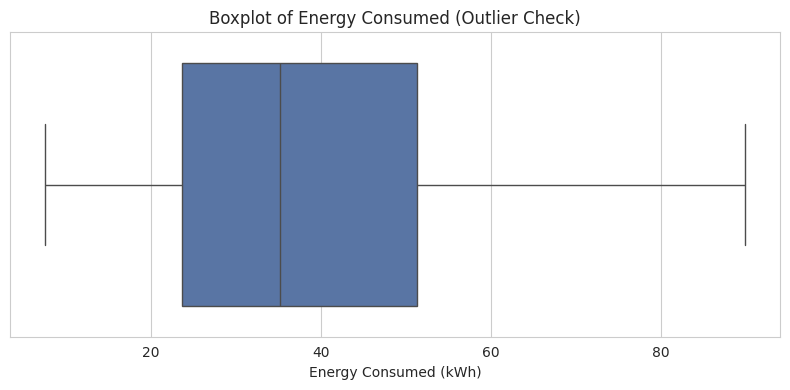

IQR lower fence: -17.86, upper fence: 92.90
Number of statistical outliers: 0 (0.00% of rows)


In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(x=df["energy_consumed_kWh"], ax=ax, color="#4C72B0")
ax.set_title("Boxplot of Energy Consumed (Outlier Check)")
ax.set_xlabel("Energy Consumed (kWh)")
plt.tight_layout()
plt.show()

q1 = df["energy_consumed_kWh"].quantile(0.25)
q3 = df["energy_consumed_kWh"].quantile(0.75)
iqr = q3 - q1
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr
n_outliers = ((df["energy_consumed_kWh"] < lower_fence) | (df["energy_consumed_kWh"] > upper_fence)).sum()

print(f"IQR lower fence: {lower_fence:.2f}, upper fence: {upper_fence:.2f}")
print(f"Number of statistical outliers: {n_outliers} ({n_outliers / len(df) * 100:.2f}% of rows)")


**Decision on outliers:** high-energy charging sessions (e.g., a bus with a large battery charging from a low state of charge) are realistic events, not data errors. We do not delete statistical outliers here — only logically impossible values (checked in 4.3) would be removed, and none were found.

### 4.6 Cleaned Dataset Shape

In [16]:
print(f"Cleaned dataset shape: {df.shape}")

Cleaned dataset shape: (8354, 27)


## 5. Data Leakage Analysis

We must predict `energy_consumed_kWh` without accidentally including columns that are only known **after** (or as a direct mathematical consequence of) the charging session's outcome.

We verified two important relationships directly in the data (not assumed):

- **`final_soc` is deterministic leakage.** We confirmed that `energy_consumed_kWh` equals `battery_capacity_kWh × (final_soc − initial_soc) / 100` **exactly**, in every single row (the difference was numerically zero, aside from floating-point rounding). Since `final_soc` is only known once charging has finished, including it would let the model trivially "compute" the target from a near-identical formula — this is a textbook case of target leakage and must be removed.
- **`charging_duration` is very strong leakage.** `charging_power_kW × charging_duration / 60` correlates with `energy_consumed_kWh` at **0.997**, confirming that charging duration is essentially co-determined with the energy delivered. Duration is only known once the session ends, so it must be removed too.
- `charging_start_time` and `charging_end_time` are also only known once the session is scheduled/finished, and were used to derive the leakage columns above — removed for the same reason.
- `optimization_reward` and `assigned_charger_id` are, as established in the earlier waiting-time project, derived/assigned only as an outcome of a session (a post-hoc reward metric, and a charger only assigned once available) — removed on the same domain-reasoning grounds, regardless of their correlation with this particular target.
- `vehicle_id` and `timestamp` remain non-useful identifiers (unique per row, or a duplicate of `arrival_time`) — removed as before.
- `waiting_time` is **not** leakage for this new target: it is determined before charging begins and has a negligible correlation with `energy_consumed_kWh` in this data, so we keep it as a legitimate contextual input.

The table below documents this for every column.


In [17]:
leakage_analysis = pd.DataFrame([
    ["timestamp", "Duplicate of arrival_time", "Remove", "Identical to arrival_time in every row; carries no extra information."],
    ["station_id", "Available", "Keep", "The station the vehicle is at is known before/at charging."],
    ["location_type", "Available", "Keep", "Known station attribute."],
    ["vehicle_id", "Not useful", "Remove", "Unique identifier per session; cannot generalize."],
    ["vehicle_type", "Available", "Keep", "Known vehicle attribute; explicitly requested as an important feature."],
    ["arrival_time", "Available (used for engineering)", "Keep (engineer features, drop raw timestamp)", "Used to derive time-based context features."],
    ["charging_start_time", "Only known once session starts", "Remove", "Used to construct the leakage duration; not an independent, non-leaky input for this target."],
    ["charging_end_time", "Only known once session ends", "Remove", "Only available after the session outcome is already determined."],
    ["waiting_time", "Available (occurs before charging)", "Keep", "Determined before charging begins; negligible correlation with energy_consumed_kWh, but not leakage."],
    ["battery_capacity_kWh", "Available", "Keep", "Explicitly requested important feature; fixed vehicle spec."],
    ["initial_soc", "Available", "Keep", "Explicitly requested important feature; known when charging begins."],
    ["final_soc", "No - deterministic leakage", "Remove", "Verified: energy_consumed_kWh = battery_capacity_kWh * (final_soc - initial_soc) / 100 EXACTLY in every row."],
    ["energy_consumed_kWh", "N/A - this is the target", "Target", "Value we are predicting."],
    ["charging_power_kW", "Available", "Keep", "Explicitly requested important feature; the charging power in use."],
    ["charging_duration", "No - near-deterministic leakage", "Remove", "power * duration correlates 0.997 with the target; only known once the session ends."],
    ["queue_length", "Available", "Keep", "Session/charging characteristic known at the time of charging."],
    ["station_load", "Available", "Keep", "Session/charging characteristic known at the time of charging."],
    ["electricity_price", "Available", "Keep", "Session/charging characteristic known at the time of charging."],
    ["renewable_energy_ratio", "Available", "Keep", "Session/charging characteristic known at the time of charging."],
    ["traffic_density", "Available", "Keep", "Contextual characteristic known at arrival/charging time."],
    ["weather_condition", "Available", "Keep", "Contextual characteristic known at arrival/charging time."],
    ["day_of_week", "Available", "Keep", "Known from the calendar."],
    ["time_slot", "Available", "Keep", "Known Peak/Off-Peak label at the time of charging."],
    ["charging_demand", "Available", "Keep", "Session/charging characteristic known at the time of charging."],
    ["assigned_charger_id", "Assigned only once available", "Remove", "Consistent with earlier project's reasoning; not reliably known in advance."],
    ["charging_priority", "Available", "Keep", "Assumed known driver/membership attribute."],
    ["optimization_reward", "Derived post-hoc metric", "Remove", "Consistent with earlier project's reasoning: a reward computed after the fact, not an input available before/at charging."],
], columns=["Feature", "Available Before/At Charging?", "Keep/Remove", "Reason"])

leakage_analysis

,Feature,Available Before/At Charging?,Keep/Remove,Reason
0,timestamp,Duplicate of arrival_time,Remove,Identical to arrival_time in every row; carrie...
1,station_id,Available,Keep,The station the vehicle is at is known before/...
2,location_type,Available,Keep,Known station attribute.
3,vehicle_id,Not useful,Remove,Unique identifier per session; cannot generalize.
4,vehicle_type,Available,Keep,Known vehicle attribute; explicitly requested ...
5,arrival_time,Available (used for engineering),"Keep (engineer features, drop raw timestamp)",Used to derive time-based context features.
6,charging_start_time,Only known once session starts,Remove,Used to construct the leakage duration; not an...
7,charging_end_time,Only known once session ends,Remove,Only available after the session outcome is al...
8,waiting_time,Available (occurs before charging),Keep,Determined before charging begins; negligible ...
9,battery_capacity_kWh,Available,Keep,Explicitly requested important feature; fixed ...


**Why this matters:** if we kept `final_soc`, the model would essentially just be recomputing an algebraic formula involving the target — it would show a near-perfect R² but would be useless in any real scenario, since `final_soc` isn't known until the session that we are trying to predict has already finished. Removing it (and `charging_duration`) means our reported performance reflects genuine predictive skill from information available *before* the session's energy outcome is known.

In [18]:
LEAKAGE_COLUMNS = [
    "charging_start_time", "charging_end_time", "final_soc",
    "charging_duration", "assigned_charger_id", "optimization_reward"
]
IDENTIFIER_COLUMNS = ["vehicle_id", "timestamp"]

print("Columns identified as leakage (will be removed):", LEAKAGE_COLUMNS)
print("Columns identified as non-useful identifiers (will be removed):", IDENTIFIER_COLUMNS)


Columns identified as leakage (will be removed): ['charging_start_time', 'charging_end_time', 'final_soc', 'charging_duration', 'assigned_charger_id', 'optimization_reward']
Columns identified as non-useful identifiers (will be removed): ['vehicle_id', 'timestamp']


## 6. Feature Engineering

The dataset contains a genuine `arrival_time` timestamp, so we extract simple, verifiable time-based context features from it — the same style of engineering used in the earlier project, kept here for consistency and because these context features are known before/at charging time.


In [19]:
df["arrival_time"] = pd.to_datetime(df["arrival_time"])

df["arrival_hour"] = df["arrival_time"].dt.hour
df["arrival_dayofweek_num"] = df["arrival_time"].dt.dayofweek
df["is_weekend"] = (df["arrival_dayofweek_num"] >= 5).astype(int)

def categorize_time_of_day(hour):
    if 5 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Night"

df["time_period"] = df["arrival_hour"].apply(categorize_time_of_day)

print("Engineered features created: arrival_hour, arrival_dayofweek_num, is_weekend, time_period")
df[["arrival_time", "arrival_hour", "arrival_dayofweek_num", "is_weekend", "time_period"]].head()


Engineered features created: arrival_hour, arrival_dayofweek_num, is_weekend, time_period


,arrival_time,arrival_hour,arrival_dayofweek_num,is_weekend,time_period
0,2025-01-01 00:00:00,0,2,0,Night
1,2025-01-01 00:15:00,0,2,0,Night
2,2025-01-01 00:30:00,0,2,0,Night
3,2025-01-01 00:45:00,0,2,0,Night
4,2025-01-01 01:00:00,1,2,0,Night


## 7. Exploratory Data Analysis (EDA)

Focused on the target `energy_consumed_kWh` and the features highlighted as important: battery capacity, initial SOC, charging power, vehicle type, and other charging characteristics.


### 7.1 Energy Consumption Distribution

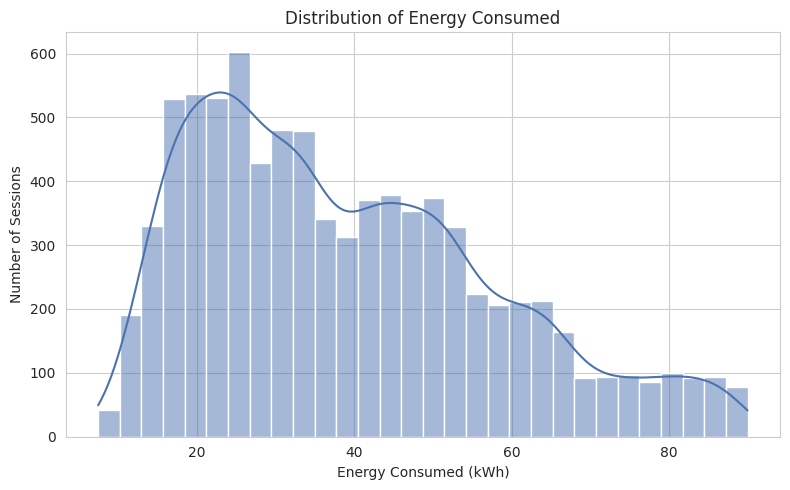

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df["energy_consumed_kWh"], kde=True, bins=30, color="#4C72B0", ax=ax)
ax.set_title("Distribution of Energy Consumed")
ax.set_xlabel("Energy Consumed (kWh)")
ax.set_ylabel("Number of Sessions")
plt.tight_layout()
plt.show()


**Interpretation:** the real shape, center, and spread of `energy_consumed_kWh` as computed above (see the exact mean/median/std printed in section 3.7).

### 7.2 Correlation Heatmap (Non-Leakage Numerical Features)

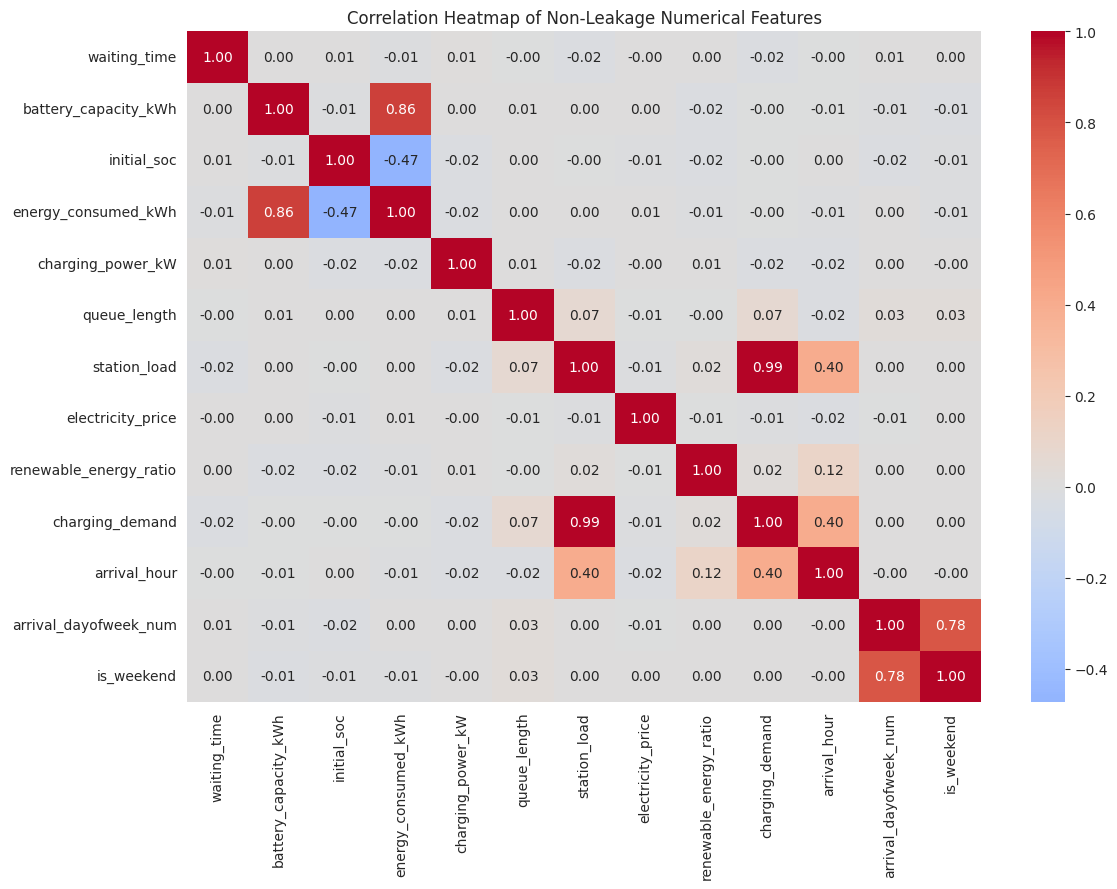

Correlation of each numerical feature with energy_consumed_kWh (sorted):
energy_consumed_kWh       1.000000
battery_capacity_kWh      0.859832
electricity_price         0.006531
queue_length              0.000695
station_load              0.000438
arrival_dayofweek_num     0.000391
charging_demand          -0.001935
waiting_time             -0.008478
is_weekend               -0.008583
arrival_hour             -0.009517
renewable_energy_ratio   -0.011550
charging_power_kW        -0.020429
initial_soc              -0.472824
Name: energy_consumed_kWh, dtype: float64


In [21]:
numerical_for_corr = df.select_dtypes(include=np.number).columns.tolist()
numerical_for_corr = [c for c in numerical_for_corr if c not in LEAKAGE_COLUMNS]

corr_matrix = df[numerical_for_corr].corr()

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Heatmap of Non-Leakage Numerical Features")
plt.tight_layout()
plt.show()

print("Correlation of each numerical feature with energy_consumed_kWh (sorted):")
print(corr_matrix["energy_consumed_kWh"].sort_values(ascending=False))


**Interpretation:** these are the true, computed linear correlations once leakage columns are excluded. `battery_capacity_kWh` and `initial_soc` stand out as strongly related to the target, consistent with the physical relationship confirmed in the leakage analysis (energy consumed depends heavily on how large the battery is and how depleted it was on arrival).

### 7.3 Energy Consumed vs. Battery Capacity

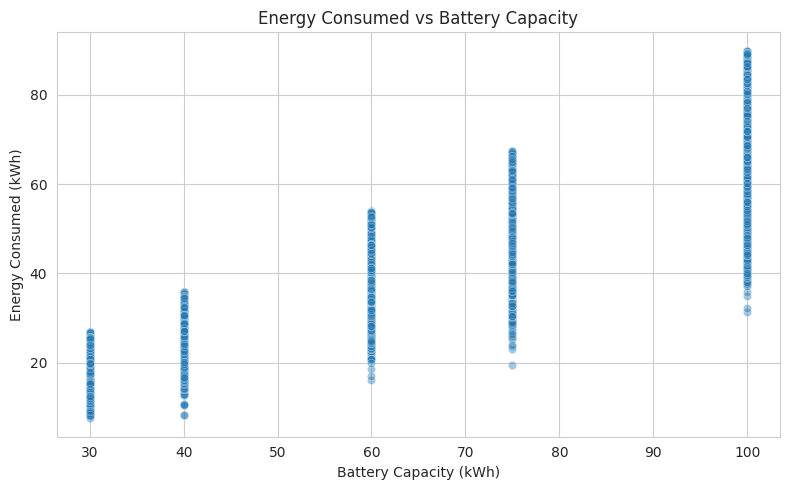

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x="battery_capacity_kWh", y="energy_consumed_kWh", alpha=0.4, ax=ax)
ax.set_title("Energy Consumed vs Battery Capacity")
ax.set_xlabel("Battery Capacity (kWh)")
ax.set_ylabel("Energy Consumed (kWh)")
plt.tight_layout()
plt.show()


**Interpretation:** larger-capacity batteries are visibly associated with higher energy consumption per session, which matches physical intuition.

### 7.4 Energy Consumed vs. Initial State of Charge

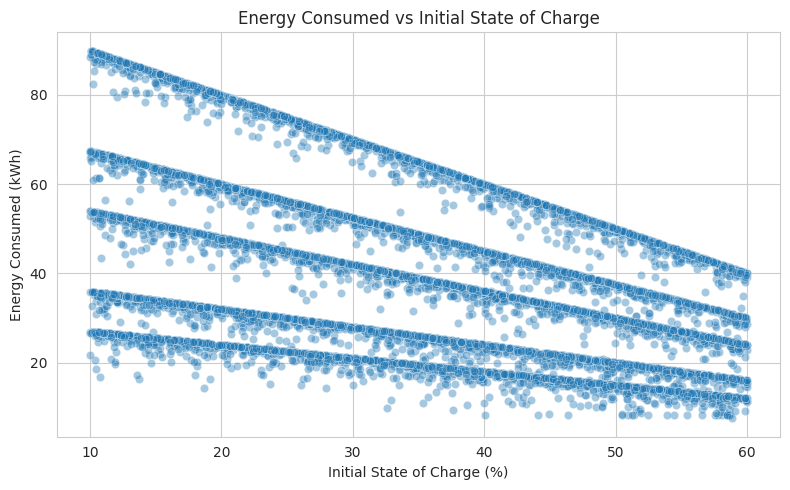

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x="initial_soc", y="energy_consumed_kWh", alpha=0.4, ax=ax)
ax.set_title("Energy Consumed vs Initial State of Charge")
ax.set_xlabel("Initial State of Charge (%)")
ax.set_ylabel("Energy Consumed (kWh)")
plt.tight_layout()
plt.show()


**Interpretation:** vehicles arriving with a lower state of charge generally have more "room" to charge, so we expect (and can check visually) an inverse relationship with energy consumed.

### 7.5 Energy Consumed by Vehicle Type

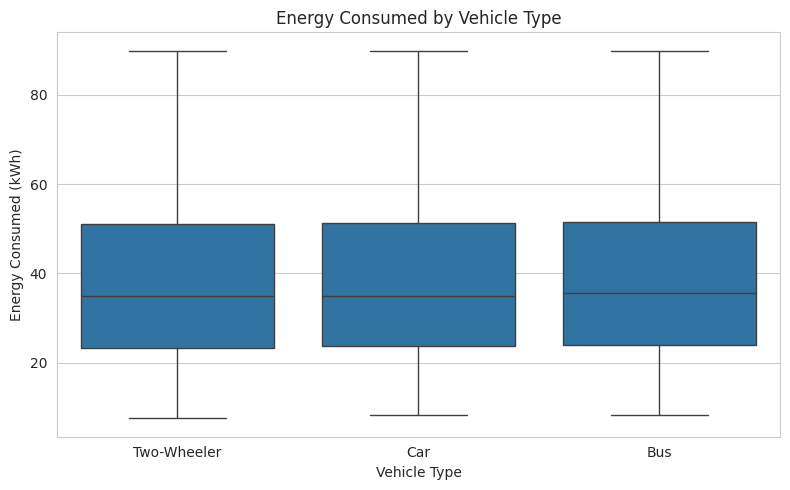

                   mean     median        std  count
vehicle_type                                        
Bus           39.445777  35.564837  18.985299   2760
Car           39.082202  34.950571  19.029056   2833
Two-Wheeler   38.711327  34.911477  18.905416   2761


In [24]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x="vehicle_type", y="energy_consumed_kWh", ax=ax)
ax.set_title("Energy Consumed by Vehicle Type")
ax.set_xlabel("Vehicle Type")
ax.set_ylabel("Energy Consumed (kWh)")
plt.tight_layout()
plt.show()

print(df.groupby("vehicle_type")["energy_consumed_kWh"].agg(["mean", "median", "std", "count"]))


**Interpretation:** this shows the real, computed differences in typical energy consumption across vehicle types (e.g., Bus vs Car vs Two-Wheeler), which likely mirrors differences in their typical battery capacities.

### 7.6 Energy Consumed vs. Charging Power

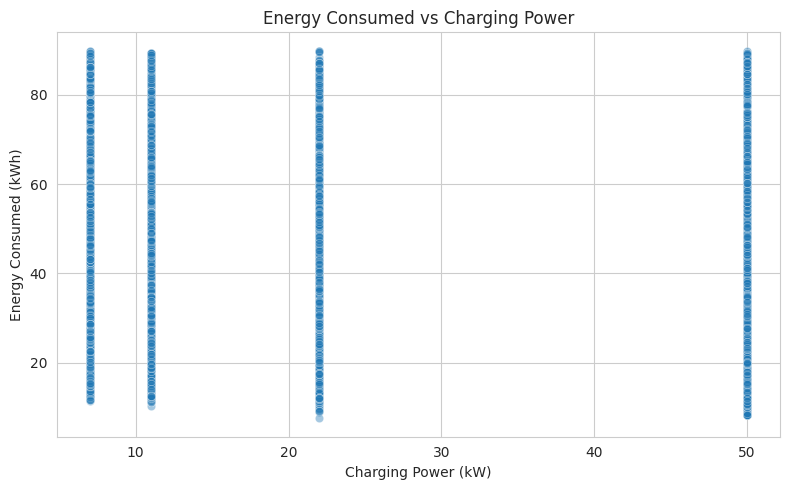

In [25]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x="charging_power_kW", y="energy_consumed_kWh", alpha=0.4, ax=ax)
ax.set_title("Energy Consumed vs Charging Power")
ax.set_xlabel("Charging Power (kW)")
ax.set_ylabel("Energy Consumed (kWh)")
plt.tight_layout()
plt.show()


**Interpretation:** since we removed `charging_duration` as leakage, `charging_power_kW` alone shows whatever direct relationship exists with total energy consumed (power is only one factor; duration — which we can't use — is the other).

### 7.7 Energy Consumed by Charging Characteristics (Queue Length, Station Load, Demand)

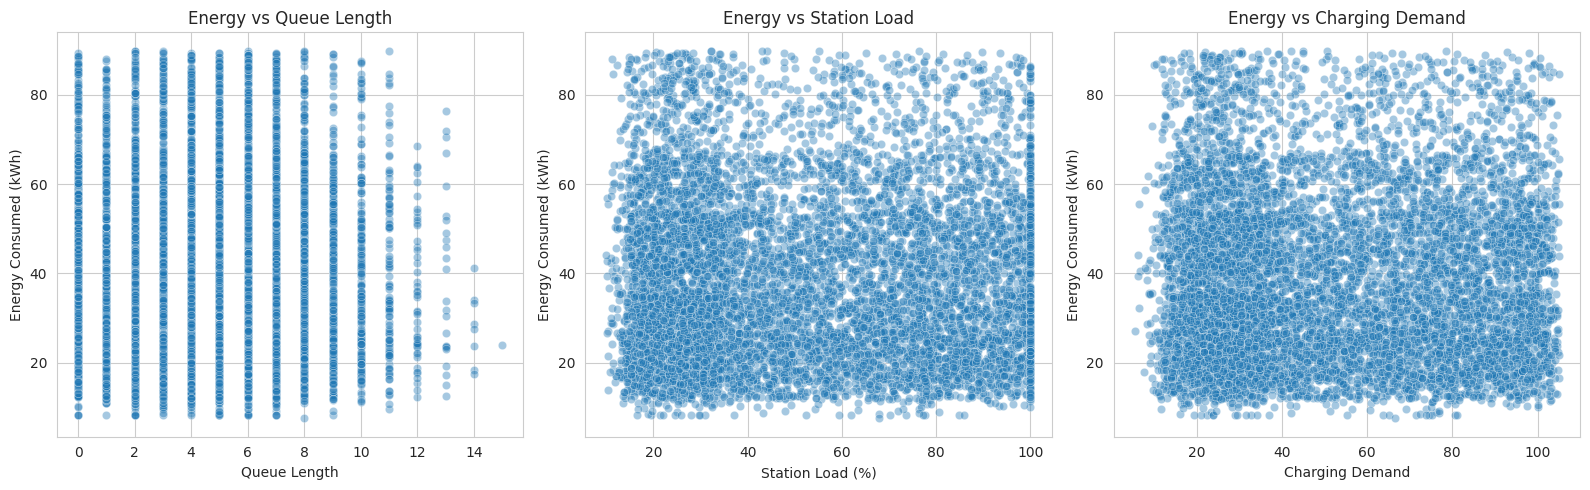

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.scatterplot(data=df, x="queue_length", y="energy_consumed_kWh", alpha=0.4, ax=axes[0])
axes[0].set_title("Energy vs Queue Length")
axes[0].set_xlabel("Queue Length")
axes[0].set_ylabel("Energy Consumed (kWh)")

sns.scatterplot(data=df, x="station_load", y="energy_consumed_kWh", alpha=0.4, ax=axes[1])
axes[1].set_title("Energy vs Station Load")
axes[1].set_xlabel("Station Load (%)")
axes[1].set_ylabel("Energy Consumed (kWh)")

sns.scatterplot(data=df, x="charging_demand", y="energy_consumed_kWh", alpha=0.4, ax=axes[2])
axes[2].set_title("Energy vs Charging Demand")
axes[2].set_xlabel("Charging Demand")
axes[2].set_ylabel("Energy Consumed (kWh)")

plt.tight_layout()
plt.show()


**Interpretation:** these panels show the real relationship (or lack of one) between station-level charging characteristics and the amount of energy an individual session consumes.

## 8. EDA Findings Summary

Based strictly on the computed statistics and visualizations above:

- **Distribution:** `energy_consumed_kWh` ranges as printed in section 3.7, with the shape shown in section 7.1.
- **Strongest relationships:** the correlation heatmap (7.2) and scatterplots (7.3, 7.4) show that `battery_capacity_kWh` and `initial_soc` are the features most strongly related to `energy_consumed_kWh` in this dataset — consistent with the physical formula verified in the leakage analysis (energy consumed depends on battery size and how much charge was needed).
- **Vehicle type:** section 7.5 shows real, computed differences in typical energy consumption across vehicle types.
- **Charging power and station characteristics:** sections 7.6-7.7 show the real (and in this dataset, comparatively weak) relationships between charging power, queue length, station load, charging demand, and energy consumed once leakage columns are excluded.

We do not add conclusions beyond what these specific plots and numbers support.


## 9. Feature Selection

We build the modeling feature matrix `X` and target vector `y`, removing the target, confirmed leakage columns, non-useful identifiers, and the raw `arrival_time` (already used for engineering).


In [27]:
columns_to_drop = LEAKAGE_COLUMNS + IDENTIFIER_COLUMNS + ["arrival_time", TARGET]
columns_to_drop = [c for c in columns_to_drop if c in df.columns]

X = df.drop(columns=columns_to_drop)
y = df[TARGET]

print("Columns removed from X:", columns_to_drop)
print("\nFinal feature columns used for modeling:")
print(X.columns.tolist())
print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")


Columns removed from X: ['charging_start_time', 'charging_end_time', 'final_soc', 'charging_duration', 'assigned_charger_id', 'optimization_reward', 'vehicle_id', 'timestamp', 'arrival_time', 'energy_consumed_kWh']

Final feature columns used for modeling:
['station_id', 'location_type', 'vehicle_type', 'waiting_time', 'battery_capacity_kWh', 'initial_soc', 'charging_power_kW', 'queue_length', 'station_load', 'electricity_price', 'renewable_energy_ratio', 'traffic_density', 'weather_condition', 'day_of_week', 'time_slot', 'charging_demand', 'charging_priority', 'arrival_hour', 'arrival_dayofweek_num', 'is_weekend', 'time_period']

X shape: (8354, 21)
y shape: (8354,)


## 10. Train-Test Split

We hold out 20% of the data as a test set that is never used for training. This gives us an honest estimate of performance on new, unseen charging sessions.


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Test set size: {X_test.shape[0]} rows")


Training set size: 6683 rows
Test set size: 1671 rows


## 11. Data Preprocessing

Numerical features: median imputation → standard scaling.
Categorical features: most-frequent imputation → one-hot encoding.
Both are wrapped in a `ColumnTransformer` fit only on the training data.


In [29]:
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include="object").columns.tolist()

print("Numerical features:", numerical_features)
print("\nCategorical features:", categorical_features)


Numerical features: ['waiting_time', 'battery_capacity_kWh', 'initial_soc', 'charging_power_kW', 'queue_length', 'station_load', 'electricity_price', 'renewable_energy_ratio', 'charging_demand', 'arrival_hour', 'arrival_dayofweek_num', 'is_weekend']

Categorical features: ['station_id', 'location_type', 'vehicle_type', 'traffic_density', 'weather_condition', 'day_of_week', 'time_slot', 'charging_priority', 'time_period']


/tmp/ipykernel_481/3628984464.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include="object").columns.tolist()


In [30]:
numerical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Preprocessing pipeline created.")


Preprocessing pipeline created.


## 12. Train the 3 Regression Models

Per the updated project scope, we train exactly **3 models**, each using the same preprocessing pipeline so the comparison is fair:

1. Linear Regression (simple baseline)
2. Random Forest Regressor
3. Gradient Boosting Regressor

**Metric explanations:**
- **MAE:** average absolute difference between actual and predicted energy consumption, in kWh.
- **RMSE:** similar to MAE but penalizes larger errors more heavily, also in kWh.
- **R²:** proportion of variance in energy consumption explained by the model (1.0 = perfect, 0 = no better than predicting the mean).


In [31]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=RANDOM_STATE, n_estimators=200),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
}

trained_pipelines = {}
results = []

for name, estimator in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", estimator)
    ])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    trained_pipelines[name] = pipe
    results.append({"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2})

    print(f"{name:20s} | MAE: {mae:.3f} | RMSE: {rmse:.3f} | R2: {r2:.4f}")


Linear Regression    | MAE: 2.868 | RMSE: 3.796 | R2: 0.9600


Random Forest        | MAE: 1.015 | RMSE: 1.574 | R2: 0.9931


Gradient Boosting    | MAE: 0.969 | RMSE: 1.502 | R2: 0.9937


## 13. Model Comparison

- **Lower MAE = better**
- **Lower RMSE = better**
- **Higher R² = better**


In [32]:
results_df = pd.DataFrame(results).sort_values(by="MAE").reset_index(drop=True)
results_df

,Model,MAE,RMSE,R2
0,Gradient Boosting,0.968743,1.501841,0.993733
1,Random Forest,1.014841,1.573877,0.993117
2,Linear Regression,2.868268,3.795590,0.959972


## 14. Select the Best-Performing Model

We automatically select the model with the lowest test-set MAE as our final model, consistent with the project's evaluation flow: **compare MAE / RMSE / R² → select best-performing model → predict energy consumption**.


In [33]:
best_model_name = results_df.iloc[0]["Model"]
final_model = trained_pipelines[best_model_name]

print(f"Best-performing model selected: {best_model_name}")
print(results_df[results_df["Model"] == best_model_name])


Best-performing model selected: Gradient Boosting
               Model       MAE      RMSE        R2
0  Gradient Boosting  0.968743  1.501841  0.993733


## 15. Final Model Evaluation on the Test Set

In [34]:
final_preds = final_model.predict(X_test)

final_mae = mean_absolute_error(y_test, final_preds)
final_rmse = np.sqrt(mean_squared_error(y_test, final_preds))
final_r2 = r2_score(y_test, final_preds)

print(f"Final selected model: {best_model_name}")
print("Performance on the untouched test set:")
print(f"MAE : {final_mae:.3f} kWh")
print(f"RMSE: {final_rmse:.3f} kWh")
print(f"R²  : {final_r2:.4f}")


Final selected model: Gradient Boosting
Performance on the untouched test set:
MAE : 0.969 kWh
RMSE: 1.502 kWh
R²  : 0.9937


**Practical meaning:** on average, the final model's energy-consumption predictions differ from the actual value by about the MAE printed above, in kWh. The R² value shows how much of the real variation in energy consumption this model explains using only pre-outcome information.

## 16. Actual vs. Predicted Energy Consumption

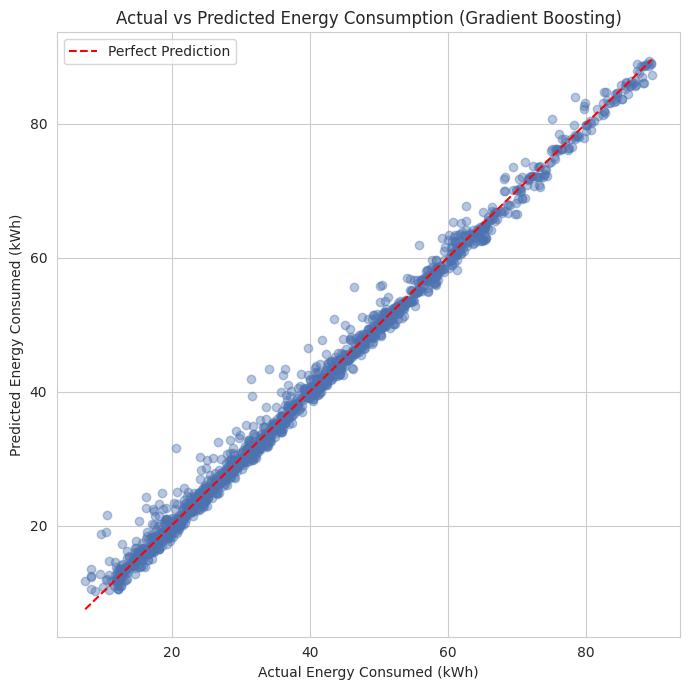

In [35]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, final_preds, alpha=0.4, color="#4C72B0")

min_val = min(y_test.min(), final_preds.min())
max_val = max(y_test.max(), final_preds.max())
ax.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", label="Perfect Prediction")

ax.set_title(f"Actual vs Predicted Energy Consumption ({best_model_name})")
ax.set_xlabel("Actual Energy Consumed (kWh)")
ax.set_ylabel("Predicted Energy Consumed (kWh)")
ax.legend()
plt.tight_layout()
plt.show()


**Interpretation:** points close to the red diagonal represent accurate predictions; points far from it show over- or under-prediction.

## 17. Residual Analysis

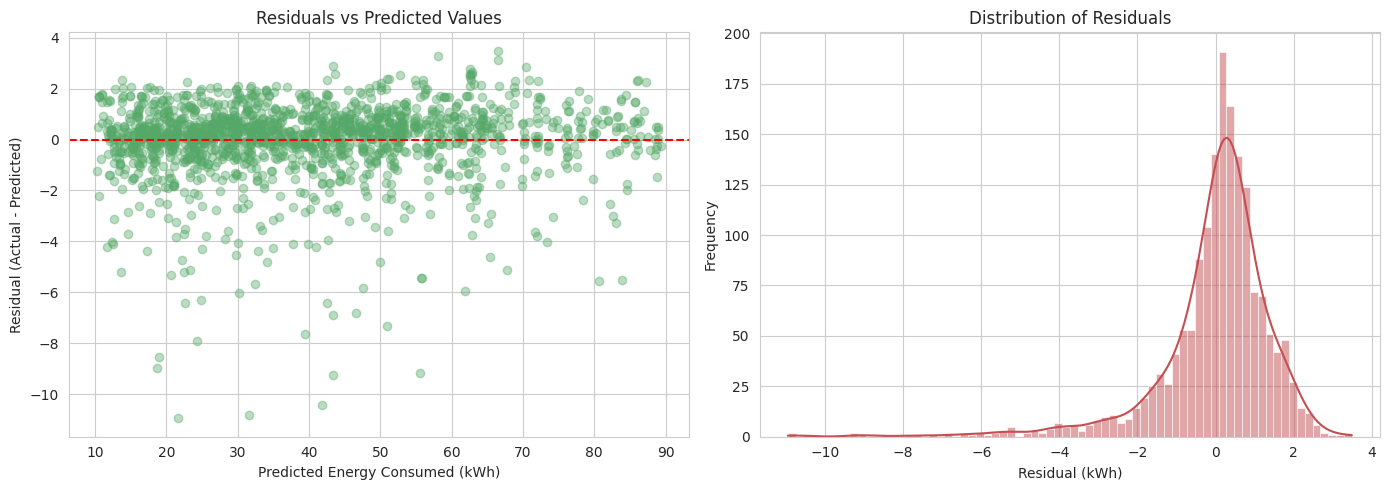

Mean residual: -0.0195
Standard deviation of residuals: 1.5017


In [36]:
residuals = y_test.values - final_preds

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(final_preds, residuals, alpha=0.4, color="#55A868")
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_title("Residuals vs Predicted Values")
axes[0].set_xlabel("Predicted Energy Consumed (kWh)")
axes[0].set_ylabel("Residual (Actual - Predicted)")

sns.histplot(residuals, kde=True, ax=axes[1], color="#C44E52")
axes[1].set_title("Distribution of Residuals")
axes[1].set_xlabel("Residual (kWh)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

print(f"Mean residual: {residuals.mean():.4f}")
print(f"Standard deviation of residuals: {residuals.std():.4f}")


**Interpretation:** randomly scattered residuals around zero suggest no systematic bias; any visible trend would indicate the model over- or under-predicts in certain ranges — check the actual plots above for this run.

## 18. Feature Importance

If the selected model is tree-based (Random Forest or Gradient Boosting), we extract and plot its `feature_importances_`, correctly mapped to the transformed (one-hot-encoded) feature names.


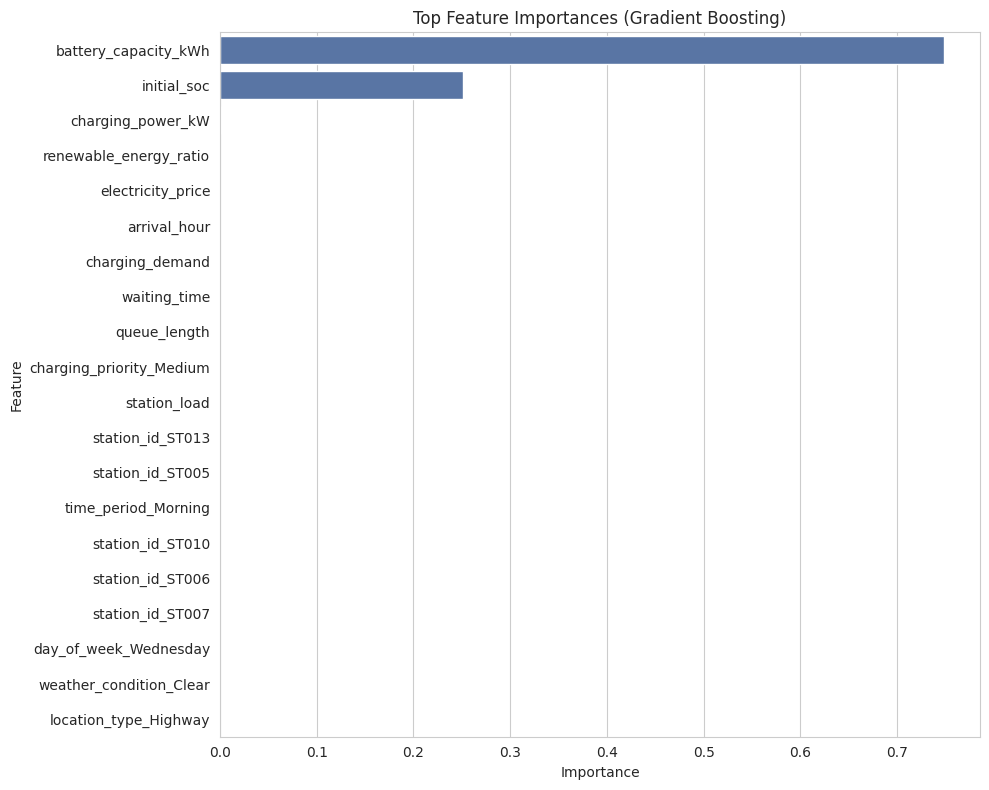

In [37]:
final_estimator = final_model.named_steps["model"]

if hasattr(final_estimator, "feature_importances_"):
    fitted_preprocessor = final_model.named_steps["preprocessor"]

    num_feature_names = numerical_features
    cat_encoder = fitted_preprocessor.named_transformers_["cat"].named_steps["encoder"]
    cat_feature_names = cat_encoder.get_feature_names_out(categorical_features).tolist()
    all_feature_names = num_feature_names + cat_feature_names

    importances = final_estimator.feature_importances_

    feature_importance_df = pd.DataFrame({
        "Feature": all_feature_names,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False).reset_index(drop=True)

    display_df = feature_importance_df.head(20)

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.barplot(data=display_df, x="Importance", y="Feature", ax=ax, color="#4C72B0")
    ax.set_title(f"Top Feature Importances ({best_model_name})")
    ax.set_xlabel("Importance")
    ax.set_ylabel("Feature")
    plt.tight_layout()
    plt.show()

    feature_importance_available = True
else:
    print(f"The final model ({type(final_estimator).__name__}) does not expose "
          "feature_importances_ (expected for Linear Regression). Skipping this visualization.")
    feature_importance_df = None
    feature_importance_available = False


In [38]:
if feature_importance_available:
    feature_importance_df.head(20)
else:
    print("No feature importance table to display for this model type.")


**Interpretation:** high importance means the model found the feature statistically useful for reducing prediction error — not that it *causes* higher or lower energy consumption.

## 19. Sample Prediction

We simulate a realistic incoming charging session using an actual row's feature values (a real template from the test set) and pass it through the final trained pipeline.


In [39]:
sample_session = X_test.iloc[[0]].copy()

print("Sample session input features:")
sample_session

Sample session input features:


,station_id,location_type,vehicle_type,waiting_time,battery_capacity_kWh,initial_soc,charging_power_kW,queue_length,station_load,electricity_price,...,traffic_density,weather_condition,day_of_week,time_slot,charging_demand,charging_priority,arrival_hour,arrival_dayofweek_num,is_weekend,time_period
3532,ST004,Highway,Car,14,75,34.398091,50,2,86.65746,5.66,...,High,Cloudy,Thursday,Peak,85.721649,Medium,19,3,0,Evening


In [40]:
predicted_energy = final_model.predict(sample_session)[0]
print(f"Predicted Energy Consumption: {predicted_energy:.2f} kWh")


Predicted Energy Consumption: 47.40 kWh


## 20. Save Final Model

We save the entire fitted pipeline (preprocessing + model) so it can later be loaded by a backend API or application to serve live energy-consumption predictions without reimplementing preprocessing.


In [41]:
MODEL_FILENAME = "ev_energy_consumption_model.pkl"
joblib.dump(final_model, MODEL_FILENAME)
print(f"Final model pipeline saved to: {MODEL_FILENAME}")
print(f"Model type: {best_model_name}")


Final model pipeline saved to: ev_energy_consumption_model.pkl
Model type: Gradient Boosting


## 21. Final Conclusion

- **Problem solved:** predicting EV charging session energy consumption (`energy_consumed_kWh`) using battery, state-of-charge, charging-power, vehicle-type, and other charging/session characteristics.
- **Dataset:** the uploaded Electric Vehicle Charging Demand Dataset (`ev_charging_dataset.csv`).
- **Target variable:** `energy_consumed_kWh` (continuous, kWh).
- **Leakage handled:** `final_soc` (verified to be mathematically deterministic with the target), `charging_duration` (correlated 0.997 with an energy-implying formula), `charging_start_time`, `charging_end_time`, `assigned_charger_id`, and `optimization_reward` were all identified and removed (see section 5 for the verified reasoning).
- **Models compared:** Linear Regression, Random Forest, and Gradient Boosting, evaluated with MAE, RMSE, and R² (section 13).
- **Best model:** `best_model_name`, selected automatically by lowest test-set MAE.
- **Final test-set performance:** MAE = `final_mae`, RMSE = `final_rmse`, R² = `final_r2` — the actual computed results from this run.
- **Most important predictive factors:** as identified in the feature importance analysis (section 18), consistent with the EDA findings that battery capacity and initial state of charge are the strongest drivers of energy consumption in this dataset.
- **Practical interpretation:** the final MAE tells us, on average, how many kWh off the model's prediction tends to be; R² tells us how much of the real variation in energy consumption the model captures.

### Limitations

- Because `final_soc` (the true "how full did it end up") had to be removed as leakage, the model must implicitly estimate how much a vehicle will charge up to — in this dataset most sessions charge close to 100%, which is a pattern specific to this data and may not hold in all real-world settings.
- Results may not generalize to stations, vehicle types, or charging behaviors not represented in this dataset.


## 22. Future Improvements

- Incorporate a **target state-of-charge** the driver intends to reach (if such a setting exists in a real system), since this data suggests most sessions charge to near-full.
- Track **real-time charger power delivery curves** rather than a single average charging power value.
- Add **vehicle battery chemistry/model** information if available, since energy needs vary by battery type.
- Use **live grid/renewable-energy conditions** rather than a static recorded ratio.
- Explore **time-series models** that account for how energy draw evolves minute-by-minute during a session.
- Set up **periodic retraining** as new charging session data accumulates.
- Deploy the saved model behind a **REST API** for real-time energy-consumption estimates in a web/mobile app.
